In [27]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

# Save model
import joblib
import os

print("All libraries imported successfully ")

All libraries imported successfully 


In [28]:
# Load dataset
df = pd.read_csv('../backend/model/online_shoppers_intention.csv')

print("Dataset loaded successfully ")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

Dataset loaded successfully 
Shape: (12330, 18)

Columns: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']


In [29]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\n Rows: {df.shape[0]}")
print(f" Columns: {df.shape[1]}")

print("\n--- Column Types ---")
print(df.dtypes)

print("\n--- First 5 Rows ---")
df.head()

DATASET OVERVIEW

 Rows: 12330
 Columns: 18

--- Column Types ---
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object

--- First 5 Rows ---


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [30]:
print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print(" No missing values found!")
else:
    # Fill missing values
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)
    print(" Missing values handled!")

MISSING VALUE ANALYSIS
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []
 No missing values found!


In [31]:
print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)

df.describe().round(2)

STATISTICAL SUMMARY


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00
mean,2.32,80.82,0.50,34.47,31.73,1194.75,0.02,0.04,5.89,0.06,2.12,2.36,3.15,4.07
std,3.32,176.78,1.27,140.75,44.48,1913.67,0.05,0.05,18.57,0.20,0.91,1.72,2.40,4.03
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,0.00,7.00,184.14,0.00,0.01,0.00,0.00,2.00,2.00,1.00,2.00
50%,1.00,7.50,0.00,0.00,18.00,598.94,0.00,0.03,0.00,0.00,2.00,2.00,3.00,2.00
75%,4.00,93.26,0.00,0.00,38.00,1464.16,0.02,0.05,0.00,0.00,3.00,2.00,4.00,4.00
max,27.00,3398.75,24.00,2549.38,705.00,63973.52,0.20,0.20,361.76,1.00,8.00,13.00,9.00,20.00


TARGET VARIABLE: Revenue (Will Customer Buy?)

Will NOT Buy (False): 10422 (84.5%)
Will Buy (True):      1908 (15.5%)


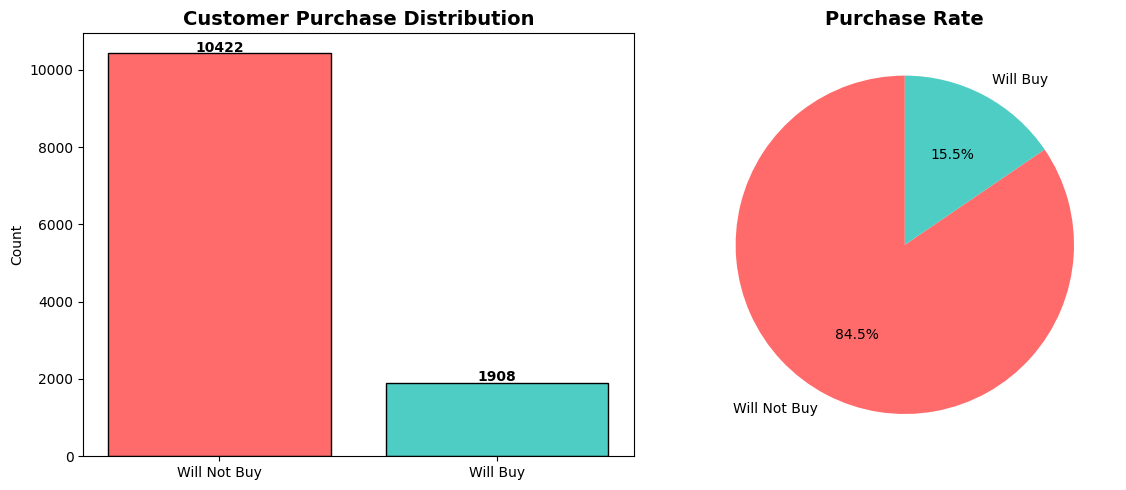

 Saved: target_distribution.png


In [32]:
print("=" * 60)
print("TARGET VARIABLE: Revenue (Will Customer Buy?)")
print("=" * 60)

target_counts = df['Revenue'].value_counts()
target_pct = df['Revenue'].value_counts(normalize=True) * 100

print(f"\nWill NOT Buy (False): {target_counts[False]} ({target_pct[False]:.1f}%)")
print(f"Will Buy (True):      {target_counts[True]} ({target_pct[True]:.1f}%)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(['Will Not Buy', 'Will Buy'], 
            [target_counts[False], target_counts[True]],
            color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[0].set_title('Customer Purchase Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([target_counts[False], target_counts[True]]):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie([target_counts[False], target_counts[True]],
            labels=['Will Not Buy', 'Will Buy'],
            colors=['#FF6B6B', '#4ECDC4'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Purchase Rate', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: target_distribution.png")

DATA VISUALIZATION


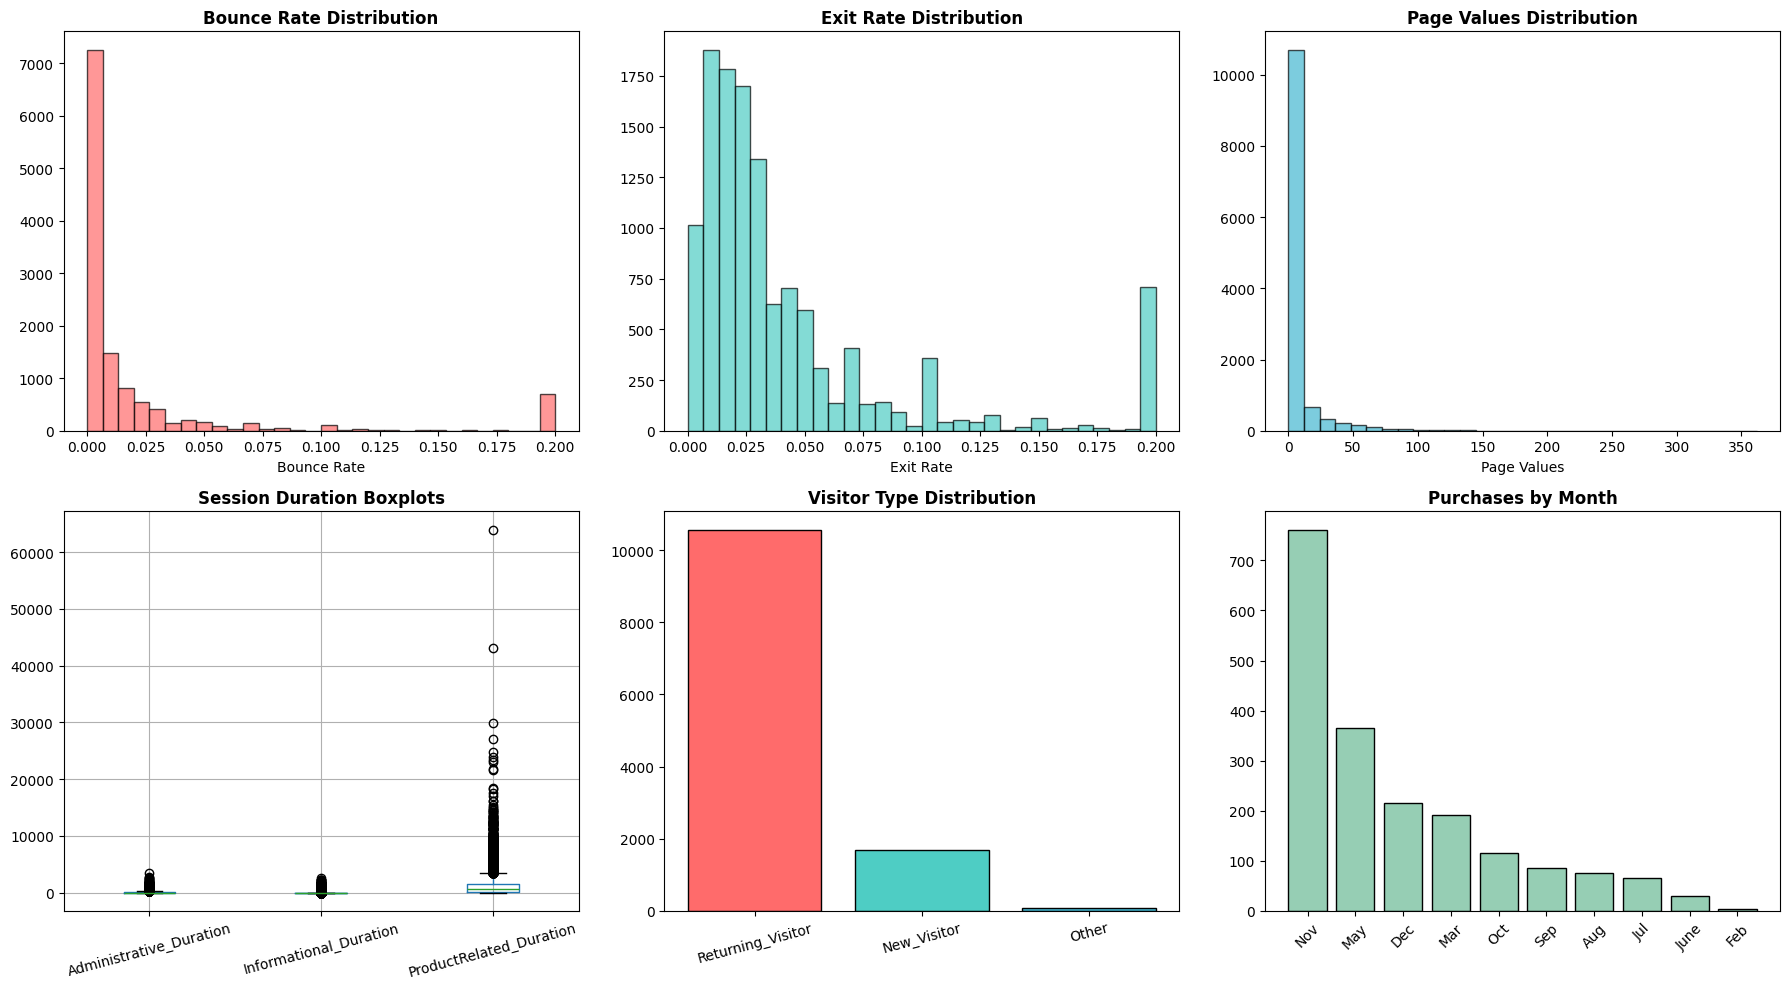

 Saved: data_visualization.png


In [33]:
print("=" * 60)
print("DATA VISUALIZATION")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Bounce Rate Distribution
axes[0,0].hist(df['BounceRates'], bins=30, color='#FF6B6B', edgecolor='black', alpha=0.7)
axes[0,0].set_title('Bounce Rate Distribution', fontweight='bold')
axes[0,0].set_xlabel('Bounce Rate')

# 2. Exit Rate Distribution
axes[0,1].hist(df['ExitRates'], bins=30, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[0,1].set_title('Exit Rate Distribution', fontweight='bold')
axes[0,1].set_xlabel('Exit Rate')

# 3. Page Values Distribution
axes[0,2].hist(df['PageValues'], bins=30, color='#45B7D1', edgecolor='black', alpha=0.7)
axes[0,2].set_title('Page Values Distribution', fontweight='bold')
axes[0,2].set_xlabel('Page Values')

# 4. Session Duration Boxplot
df.boxplot(column=['Administrative_Duration', 'Informational_Duration', 
                    'ProductRelated_Duration'], ax=axes[1,0])
axes[1,0].set_title('Session Duration Boxplots', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=15)

# 5. Visitor Type
visitor_counts = df['VisitorType'].value_counts()
axes[1,1].bar(visitor_counts.index, visitor_counts.values,
              color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black')
axes[1,1].set_title('Visitor Type Distribution', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=15)

# 6. Month wise purchases
month_revenue = df.groupby('Month')['Revenue'].sum().sort_values(ascending=False)
axes[1,2].bar(month_revenue.index, month_revenue.values, color='#96CEB4', edgecolor='black')
axes[1,2].set_title('Purchases by Month', fontweight='bold')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('data_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: data_visualization.png")

CORRELATION ANALYSIS & OUTLIER DETECTION


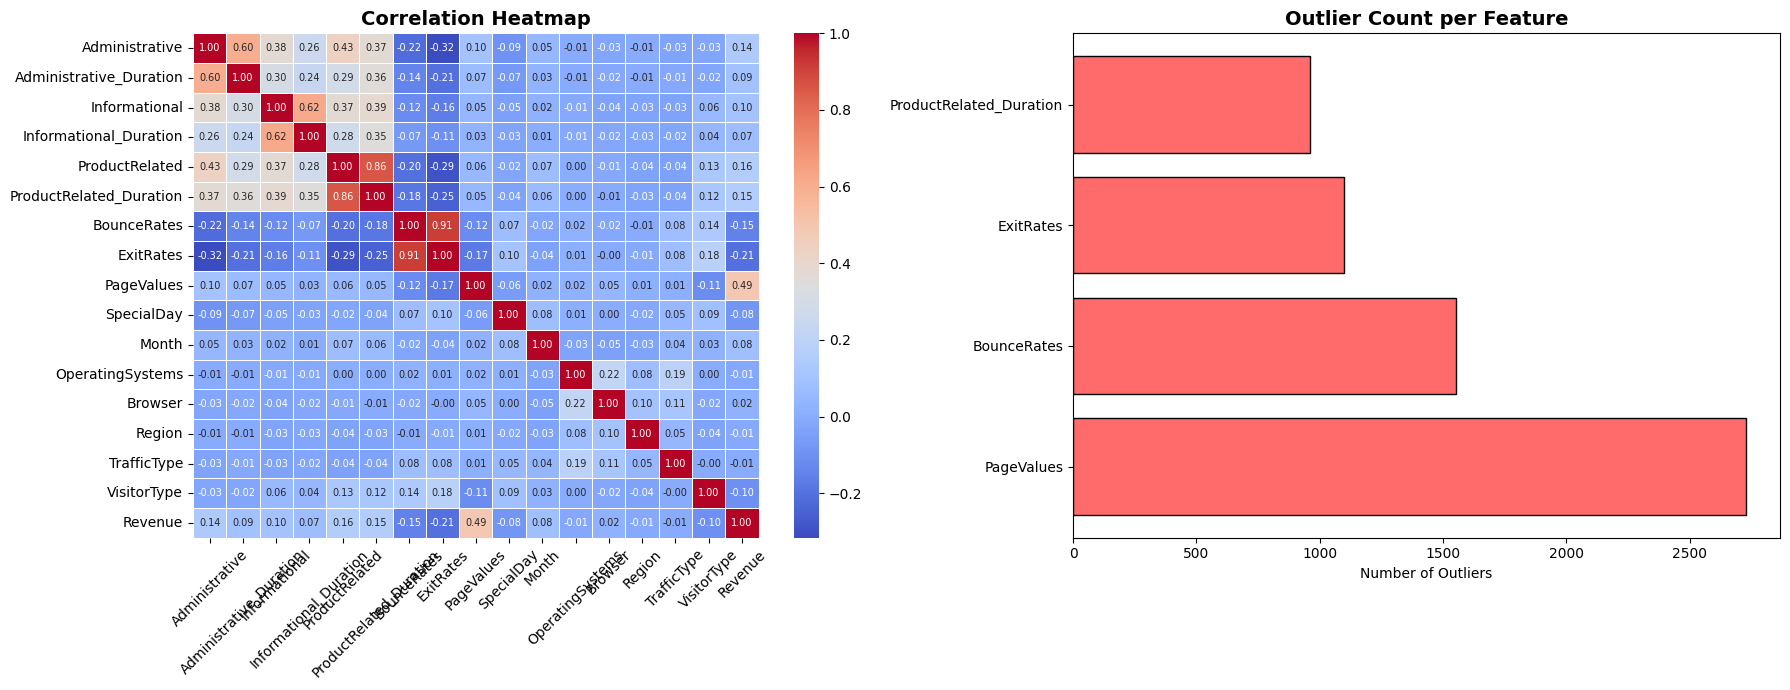


Outlier Summary:
  PageValues: 2730 outliers
  BounceRates: 1551 outliers
  ExitRates: 1099 outliers
  ProductRelated_Duration: 961 outliers
Saved: correlation_outliers.png


In [34]:
print("=" * 60)
print("CORRELATION ANALYSIS & OUTLIER DETECTION")
print("=" * 60)

# Encode for correlation
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])
df_encoded['Revenue'] = df_encoded['Revenue'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Correlation Heatmap
numeric_cols = df_encoded.select_dtypes(include=np.number).columns
corr_matrix = df_encoded[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], linewidths=0.5, annot_kws={'size': 7})
axes[0].set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Outlier Detection using IQR
outlier_cols = ['PageValues', 'BounceRates', 'ExitRates', 
                'ProductRelated_Duration']
outlier_counts = {}
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    outlier_counts[col] = len(outliers)

axes[1].barh(list(outlier_counts.keys()), list(outlier_counts.values()),
             color='#FF6B6B', edgecolor='black')
axes[1].set_title('Outlier Count per Feature', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Outliers')

plt.tight_layout()
plt.savefig('correlation_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nOutlier Summary:")
for col, count in outlier_counts.items():
    print(f"  {col}: {count} outliers")
print("Saved: correlation_outliers.png")

In [35]:
print("=" * 60)
print("PREPROCESSING")
print("=" * 60)

df_model = df_encoded.copy()

# Features and target
X = df_model.drop('Revenue', axis=1)
y = df_model['Revenue']

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Target distribution:\n{y.value_counts()}")

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set: {X_train_scaled.shape}")
print(f"Testing set:  {X_test_scaled.shape}")
print("Preprocessing complete!")

PREPROCESSING
Features: 17
Samples: 12330
Target distribution:
Revenue
0    10422
1     1908
Name: count, dtype: int64

Training set: (9864, 17)
Testing set:  (2466, 17)
Preprocessing complete!


In [36]:
print("=" * 60)
print("MODEL TRAINING")
print("=" * 60)

results = {}

# 1. Logistic Regression
print("\n Training Logistic Regression...")
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
results['Logistic Regression'] = {
    'model': lr, 'pred': lr_pred, 'prob': lr_prob}
print(" Done!")

# 2. Random Forest
print("\n Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_prob = rf.predict_proba(X_test_scaled)[:, 1]
results['Random Forest'] = {
    'model': rf, 'pred': rf_pred, 'prob': rf_prob}
print(" Done!")

# 3. KNN
print("\n Training KNN...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
knn_prob = knn.predict_proba(X_test_scaled)[:, 1]
results['KNN'] = {
    'model': knn, 'pred': knn_pred, 'prob': knn_prob}
print(" Done!")

print("\n All models trained!")

MODEL TRAINING

 Training Logistic Regression...
 Done!

 Training Random Forest...
 Done!

 Training KNN...
 Done!

 All models trained!


In [37]:
print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

eval_results = []

for name, res in results.items():
    acc = accuracy_score(y_test, res['pred'])
    prec = precision_score(y_test, res['pred'])
    rec = recall_score(y_test, res['pred'])
    f1 = f1_score(y_test, res['pred'])
    roc = roc_auc_score(y_test, res['prob'])
    
    eval_results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc, 4)
    })
    
    print(f"\n{'='*40}")
    print(f" {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, res['pred'], 
          target_names=['No Purchase', 'Purchase']))

eval_df = pd.DataFrame(eval_results)
print("\n--- MODEL COMPARISON TABLE ---")
print(eval_df.to_string(index=False))

MODEL EVALUATION

 Logistic Regression
              precision    recall  f1-score   support

 No Purchase       0.89      0.98      0.93      2084
    Purchase       0.76      0.36      0.49       382

    accuracy                           0.88      2466
   macro avg       0.83      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466


 Random Forest
              precision    recall  f1-score   support

 No Purchase       0.92      0.96      0.94      2084
    Purchase       0.74      0.56      0.64       382

    accuracy                           0.90      2466
   macro avg       0.83      0.76      0.79      2466
weighted avg       0.89      0.90      0.89      2466


 KNN
              precision    recall  f1-score   support

 No Purchase       0.89      0.96      0.92      2084
    Purchase       0.62      0.37      0.47       382

    accuracy                           0.87      2466
   macro avg       0.76      0.67      0.70      2466
weighted avg 

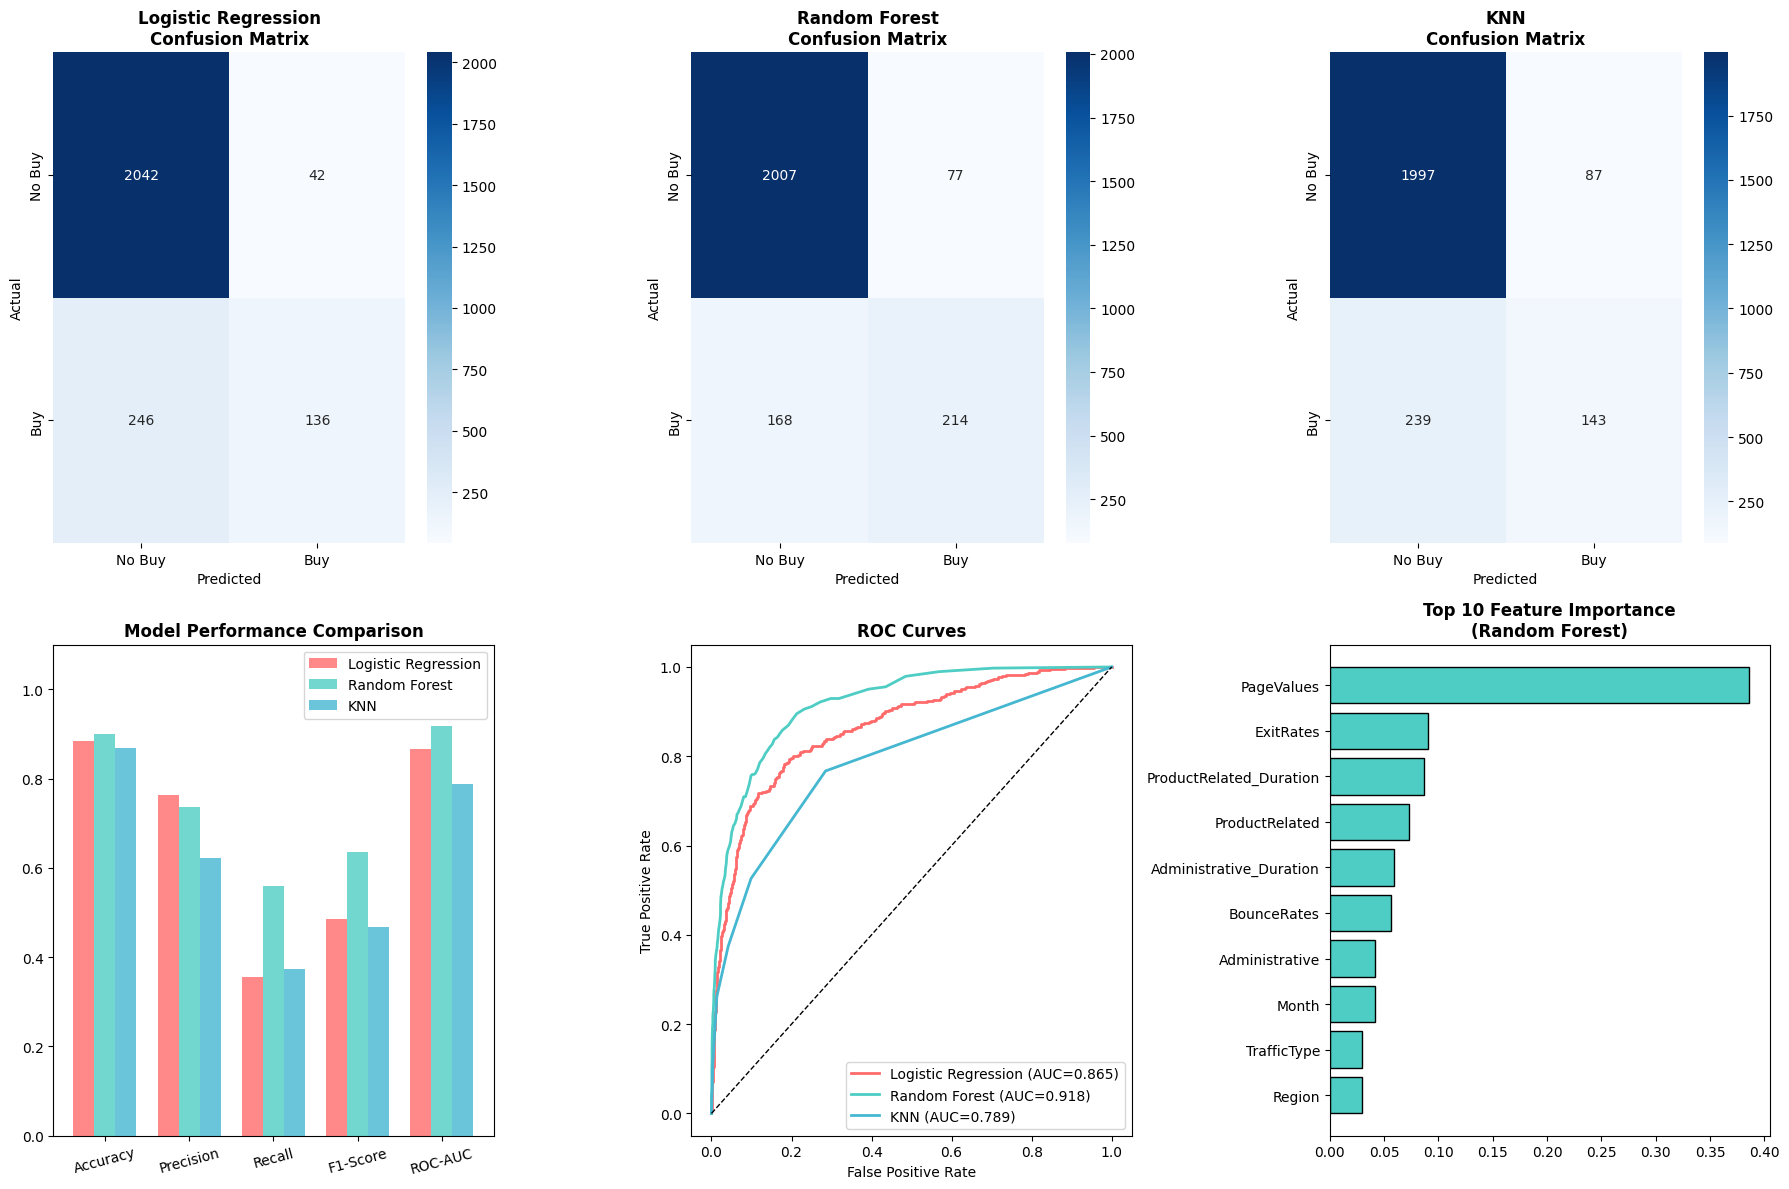

 Saved: model_evaluation.png


In [38]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

model_names = list(results.keys())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Confusion matrices
for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes[0, idx],
                xticklabels=['No Buy', 'Buy'],
                yticklabels=['No Buy', 'Buy'])
    axes[0, idx].set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    axes[0, idx].set_ylabel('Actual')
    axes[0, idx].set_xlabel('Predicted')

# Model comparison bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

for idx, row in eval_df.iterrows():
    values = [row[m] for m in metrics]
    axes[1, 0].bar(x + idx*width, values, width, 
                   label=row['Model'], color=colors[idx], alpha=0.8)

axes[1, 0].set_title('Model Performance Comparison', fontweight='bold')
axes[1, 0].set_xticks(x + width)
axes[1, 0].set_xticklabels(metrics, rotation=15)
axes[1, 0].legend()
axes[1, 0].set_ylim(0, 1.1)

# ROC Curves
for idx, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    auc = roc_auc_score(y_test, res['prob'])
    axes[1, 1].plot(fpr, tpr, color=colors[idx], 
                    label=f'{name} (AUC={auc:.3f})', linewidth=2)

axes[1, 1].plot([0,1],[0,1], 'k--', linewidth=1)
axes[1, 1].set_title('ROC Curves', fontweight='bold')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].legend()

# Feature importance (Random Forest)
feat_imp = pd.Series(rf.feature_importances_, 
                      index=X.columns).sort_values(ascending=True).tail(10)
axes[1, 2].barh(feat_imp.index, feat_imp.values, color='#4ECDC4', edgecolor='black')
axes[1, 2].set_title('Top 10 Feature Importance\n(Random Forest)', fontweight='bold')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: model_evaluation.png")

In [39]:
print("=" * 60)
print("SAVING BEST MODEL")
print("=" * 60)

# Pick best model by ROC-AUC
best_row = eval_df.loc[eval_df['ROC-AUC'].idxmax()]
best_name = best_row['Model']
best_model = results[best_name]['model']

print(f"\n🏆 Best Model: {best_name}")
print(f"   ROC-AUC: {best_row['ROC-AUC']}")
print(f"   Accuracy: {best_row['Accuracy']}")

# Save model and scaler
os.makedirs('../backend/model', exist_ok=True)
joblib.dump(best_model, '../backend/model/model.pkl')
joblib.dump(scaler, '../backend/model/preprocessor.pkl')

# Save feature names
import json
with open('../backend/model/features.json', 'w') as f:
    json.dump(list(X.columns), f)

print("\n✅ Model saved → backend/model/model.pkl")
print("✅ Scaler saved → backend/model/preprocessor.pkl")
print("✅ Features saved → backend/model/features.json")
print("\n🎉 NOTEBOOK COMPLETE!")

SAVING BEST MODEL

🏆 Best Model: Random Forest
   ROC-AUC: 0.9183
   Accuracy: 0.9006

✅ Model saved → backend/model/model.pkl
✅ Scaler saved → backend/model/preprocessor.pkl
✅ Features saved → backend/model/features.json

🎉 NOTEBOOK COMPLETE!
